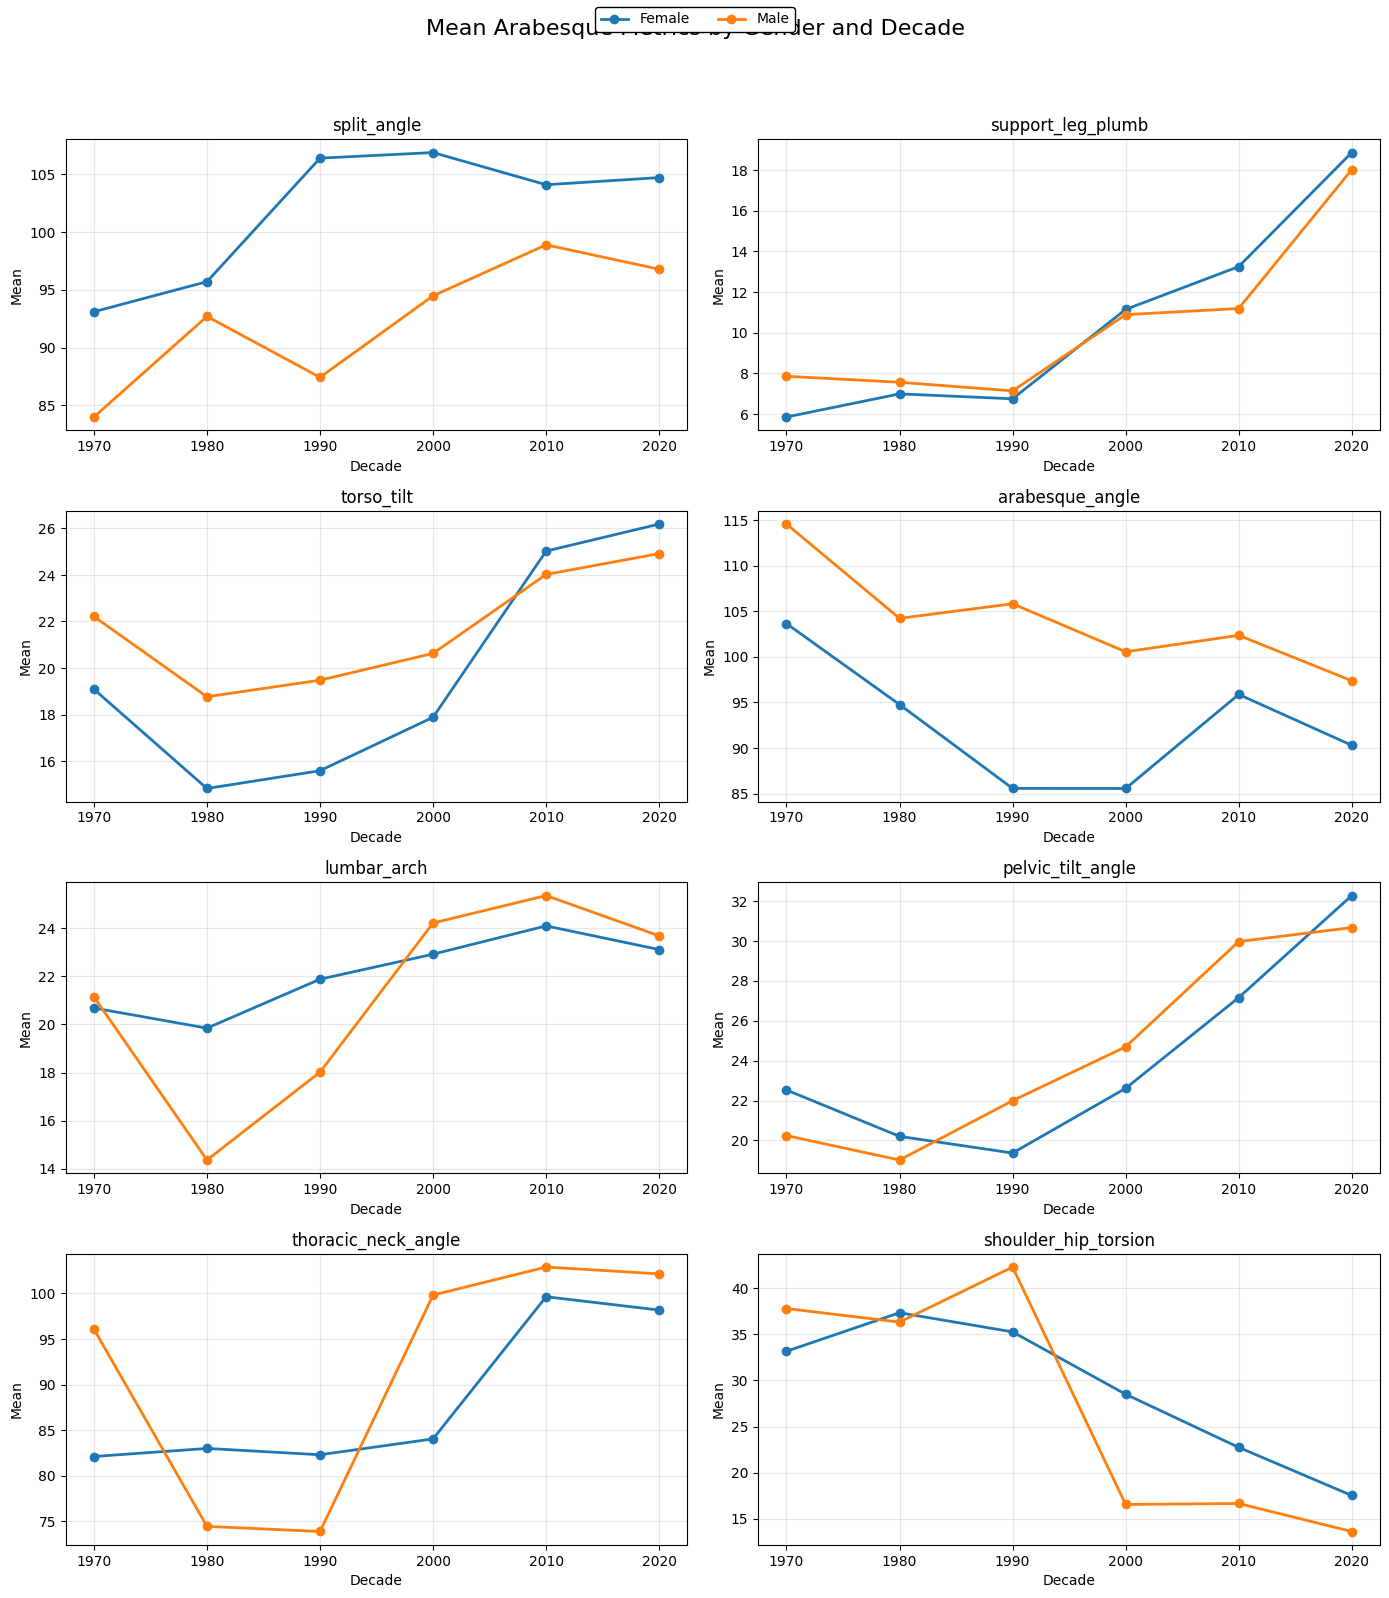

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Data/arabesque_cleaned_for_analysis_full.csv")

df["gender_label"] = df["real_gender"].map({
    "F": "Female",
    "M": "Male"
})

motion_metrics = [
    "split_angle",
    "support_leg_plumb",
    "torso_tilt",
    "arabesque_angle",
    "lumbar_arch",
    "pelvic_tilt_angle",
    "thoracic_neck_angle",
    "shoulder_hip_torsion"
]

gender_mean_by_decade = (
    df
    .dropna(subset=["gender_label"])
    .groupby(["decade", "gender_label"])[motion_metrics]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, metric in zip(axes, motion_metrics):
    for gender in ["Female", "Male"]:
        sub = gender_mean_by_decade[
            gender_mean_by_decade["gender_label"] == gender
        ].sort_values("decade")

        ax.plot(
            sub["decade"],
            sub[metric],
            marker="o",
            linewidth=2,
            label=gender
        )

    ax.set_title(metric)
    ax.set_xlabel("Decade")
    ax.set_ylabel("Mean")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()

legend = fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=True
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("black")
legend.get_frame().set_alpha(1)

fig.suptitle(
    "Mean Arabesque Metrics by Gender and Decade",
    fontsize=16,
    y=0.99
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

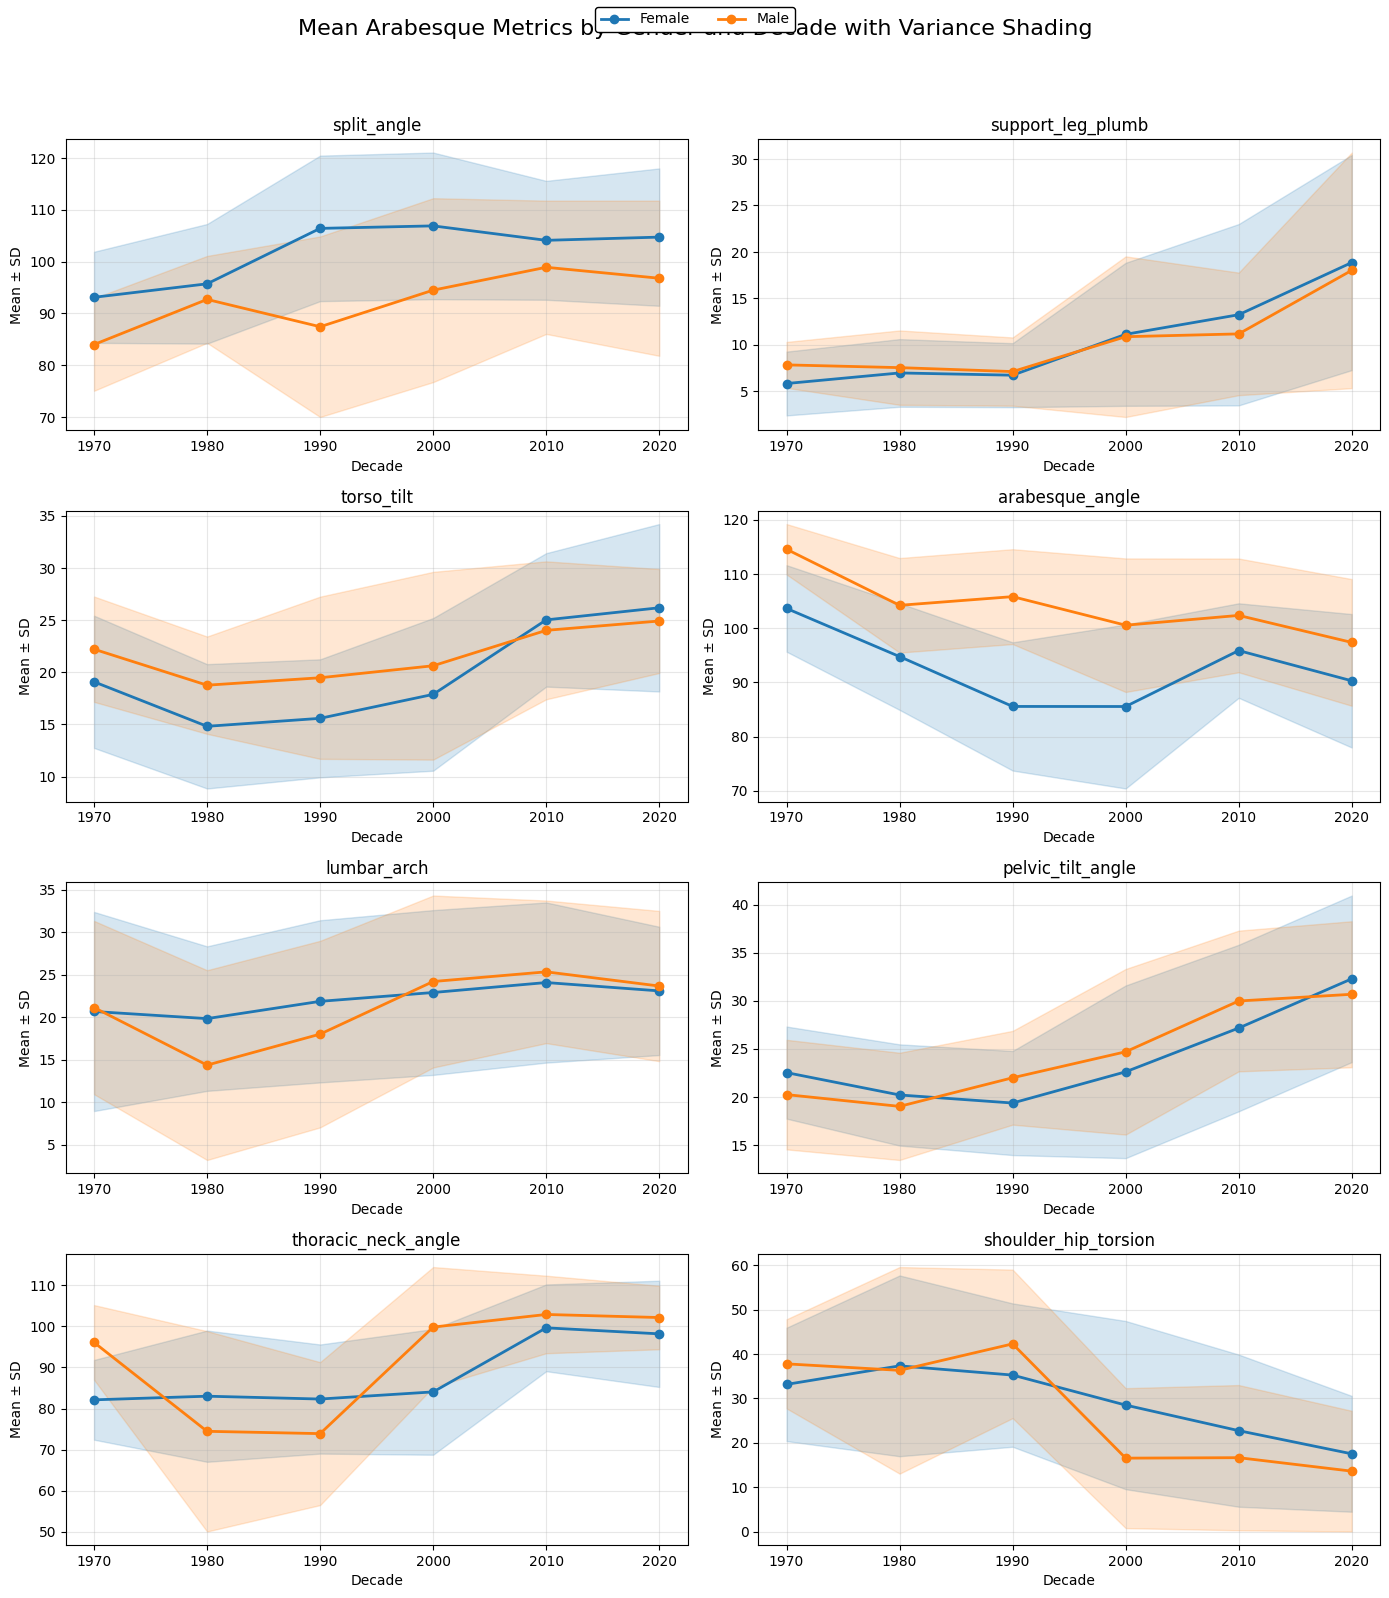

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Data/arabesque_cleaned_for_analysis_full.csv")

df["gender_label"] = df["real_gender"].map({
    "F": "Female",
    "M": "Male"
})

motion_metrics = [
    "split_angle",
    "support_leg_plumb",
    "torso_tilt",
    "arabesque_angle",
    "lumbar_arch",
    "pelvic_tilt_angle",
    "thoracic_neck_angle",
    "shoulder_hip_torsion"
]

gender_stats_by_decade = (
    df
    .dropna(subset=["gender_label"])
    .groupby(["decade", "gender_label"])[motion_metrics]
    .agg(["mean", "std"])
)

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

colors = {
    "Female": "tab:blue",
    "Male": "tab:orange"
}

for ax, metric in zip(axes, motion_metrics):
    for gender in ["Female", "Male"]:
        sub = gender_stats_by_decade.xs(gender, level="gender_label")
        sub = sub.sort_index()

        x = sub.index.astype(str)
        mean = sub[(metric, "mean")]
        std = sub[(metric, "std")]

        ax.plot(
            x,
            mean,
            marker="o",
            linewidth=2,
            label=gender,
            color=colors[gender]
        )

        ax.fill_between(
            x,
            mean - std,
            mean + std,
            color=colors[gender],
            alpha=0.18
        )

    ax.set_title(metric)
    ax.set_xlabel("Decade")
    ax.set_ylabel("Mean ± SD")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()

legend = fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=True
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("black")
legend.get_frame().set_alpha(1)

fig.suptitle(
    "Mean Arabesque Metrics by Gender and Decade with Variance Shading",
    fontsize=16,
    y=0.99
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()